In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from scipy.integrate import trapezoid
from scipy.stats import linregress

from amocatlas import read
from correlation_trends import geostrophy, filters

In [2]:
figpath = "../figures/"

In [3]:
## Read the datasets

# 26N transports: MOC, TRANS_FC, TRANS_EKMAN, TRANS_UMO
transports = read.rapid()

# 26N boundary hydrography for Part 1 (TEMP_/PSAL_ WEST & EAST on PRESSURE)

MOC = transports.MOC
TRANS_FC = transports.TRANS_FC
TRANS_EKMAN = transports.TRANS_FC
TRANS_UMO = transports.TRANS_UMO

# 26N boundary hydrography for Part 1 (TEMP_/PSAL_ WEST & EAST on PRESSURE)
ts = read.rapid(file_list=["ts_gridded.nc"], transport_only=False)
# 26N overturning in density coordinates: MOC_SIGMA0
mt = read.rapid(file_list=["meridional_transports.nc"], transport_only=False)
# 47N NOAC overturning (monthly): MOC_SIGMA0
noac = read.read_47n()

Loading 1 RAPID 26°N dataset(s):
  0. moc_transports.nc: RAPID layer transport time series

Loading 1 RAPID 26°N dataset(s):
  0. ts_gridded.nc: RAPID gridded temperature and salinity

Loading 1 RAPID 26°N dataset(s):
  0. meridional_transports.nc: RAPID meridional transport data

Loading 1 NOAC 47°N dataset(s):
  0. NOAC_AMOC.tab: Basin-wide AMOC volume transport from the NOAC array at 47°N in the subpolar North Atlantic (1993-2018)



In [4]:
PSAL_WEST = ts.PSAL_WEST
PSAL_EAST = ts.PSAL_EAST
T_WEST = ts.TEMP_WEST
T_EAST = ts.TEMP_EAST
p = ts.PRESSURE

In [5]:
f = 2 * 7.292e-5 * np.sin(26 / 180 * np.pi) # coriolis parameter for 26° N

In [6]:
# # converting to TEOS-10 units
# TS_WEST = geostrophy.to_teos10(temp=T_WEST,salt = PSAL_WEST,pres = p,lat = 26.52,lon = -76.74)
# np.save("data/TS_WEST.npy",TS_WEST)
# TS_EAST = geostrophy.to_teos10(temp=T_EAST,salt = PSAL_EAST,pres = p,lat = 26.99,lon = -16.23)
# np.save("data/TS_EAST.npy",TS_EAST)

In [7]:
TS_WEST = np.load("../data/TS_WEST.npy")
TS_EAST = np.load("../data/TS_EAST.npy")

In [8]:
#using reference pressure pref, calculate dynamic height
pref = 4820.0 #dBar
dynamic_height_west_nan = geostrophy.dynamic_height(TS_WEST[0].T,TS_WEST[1].T,p,pref) # have to transpose the arrays, otherwise the pressure is on the wrong axis
dynamic_height_east_nan = geostrophy.dynamic_height(TS_EAST[0].T,TS_EAST[1].T,p,pref)
dynamic_height_west = geostrophy._fill_profiles(dynamic_height_west_nan,p)
dynamic_height_east = geostrophy._fill_profiles(dynamic_height_east_nan,p)

In [9]:
# prob dont need it
# def great_circle_distance(lat1, lon1, lat2, lon2): 
#     # coordinates in degrees
#     R = 6.37e6 #earths radius in m
#     coordinates = np.deg2rad(np.array([[lat1, lon1], [lat2, lon2]]))
#     phi1 = coordinates[0,0]
#     phi2 = coordinates[1,0]
#     lam1 = coordinates[0,1]
#     lam2 = coordinates[1,1]
#     del_phi = phi2-phi1
#     del_lam = lam2-lam1
#     a = np.sin(del_phi/2)**2+np.cos(phi1)*np.cos(phi2)*np.sin(del_lam/2)**2
#     c = 2 * np.atan2(np.sqrt(a),np.sqrt(1-a))
#     d = R*c
#     return(d)
# print(great_circle_distance(26.52,-76.74,26.99,-16.23))

In [10]:
#difference the dynamics heights to get zonally-integrated geostrophic transport per unit depth (EAST MINUS WEST, is just convention and either N or S transport)
#fix the calculation by properly calculating streamfunction from dynamic height
psi_difference = dynamic_height_east - dynamic_height_west
#get transport
delta_x = 6.37e6*np.cos(np.deg2rad(26))*np.deg2rad(76.74-16.23) # not sure we need it 
thermal_wind = psi_difference / f #m^2/s zonally-integrated geostrophic transport per unit depth
#integrate until 1100 m (or dbar for that matter)
transport = trapezoid(y = thermal_wind[:55,:],x = p.values[:55],dx = 20e4,axis = 0) / 1e6 # converted to Sverdrup unit

In [11]:
nan_indices_in_RAPID_TRANSPORTS = (np.argwhere(np.isnan(TRANS_UMO.values))) 

In [12]:
filtered_transport_geostrophy = filters.tukey_lowpass(transport,window = 20) # introduce 10 day lowpass

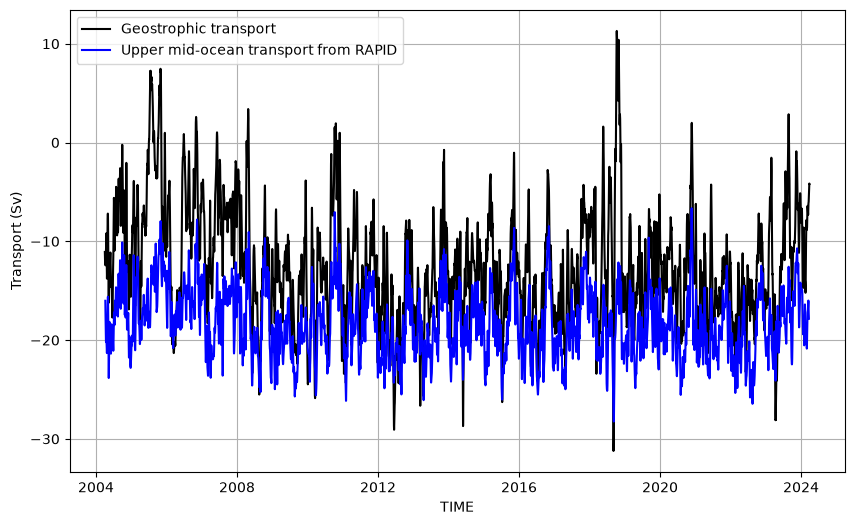

In [13]:
plt.figure(figsize=[10,6])
plt.plot(TRANS_UMO["TIME"],filtered_transport_geostrophy, color ="k",label = "Geostrophic transport")
plt.plot(TRANS_UMO["TIME"],TRANS_UMO,color = "blue", label = "Upper mid-ocean transport from RAPID")
#plt.plot(filtered_transport_geostrophy[:100], color ="k",label = "Geostrophic transport")
#plt.plot(transport[:100], color ="k",label = "Geostrophic transport")
#plt.plot(TRANS_UMO[:100],color = "blue", label = "Upper mid-ocean transport from RAPID")
plt.grid()
plt.xlabel("TIME")
plt.ylabel("Transport (Sv)")
plt.legend()

In [14]:
# have some issues with missing values in 
r = np.corrcoef(filtered_transport_geostrophy[10:-10]/1e6, TRANS_UMO.values[10:-10])
r_unfiltered = np.corrcoef(transport[10:-10]/1e6, TRANS_UMO.values[10:-10])
print(r[0,1])
print(r_unfiltered[0,1])

0.7741004424529536
0.7522982951152986


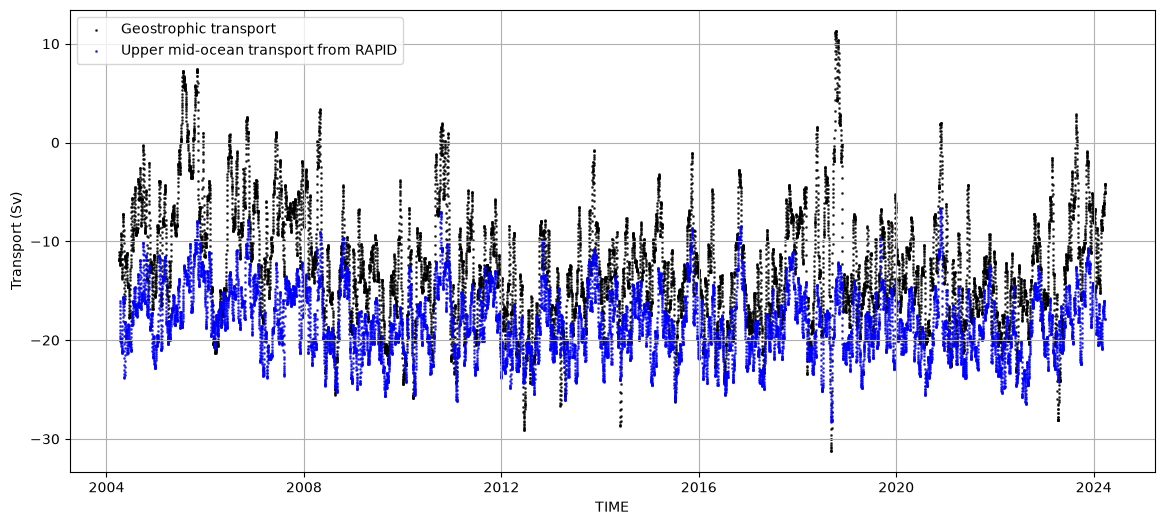

In [16]:
plt.figure(figsize=[14,6])
plt.scatter(TRANS_UMO["TIME"],filtered_transport_geostrophy, color ="k",label = "Geostrophic transport",s = 1, alpha = 0.7)
plt.scatter(TRANS_UMO["TIME"],TRANS_UMO,color = "blue", label = "Upper mid-ocean transport from RAPID", s = 1, alpha = 0.7)
#plt.plot(TRANS_UMO["TIME"], trend_geostrophy_plot, color = "red", lw = 12)
#plt.plot(TRANS_UMO["TIME"][10:-10], trend_UMO_plot, color = "red", lw = 12)
plt.grid()
plt.xlabel("TIME")
plt.ylabel("Transport (Sv)")
plt.legend()

In [17]:
trend_geostrophy = linregress(np.arange(len(filtered_transport_geostrophy)),filtered_transport_geostrophy)
trend_UMO = linregress(np.arange(len(filtered_transport_geostrophy[10:-10])),TRANS_UMO.values[10:-10])

In [18]:
trend_geostrophy_plot = trend_geostrophy.intercept + np.arange(len(filtered_transport_geostrophy)) * trend_geostrophy.slope
trend_UMO_plot = trend_UMO.intercept + np.arange(len(filtered_transport_geostrophy[10:-10])) * trend_UMO.slope

In [19]:
trend_geostrophy

LinregressResult(slope=np.float64(-0.0002780695335604905), intercept=np.float64(-10.501182938533123), rvalue=np.float64(-0.1996302543384879), pvalue=np.float64(4.1047999229481306e-131), stderr=np.float64(1.1297029977030947e-05), intercept_stderr=np.float64(0.09521479804018435))

In [20]:
trend_UMO

LinregressResult(slope=np.float64(-0.00014564129182175972), intercept=np.float64(-17.30693298287754), rvalue=np.float64(-0.1793814155063685), pvalue=np.float64(1.0885925517425566e-105), stderr=np.float64(6.615623981985896e-06), intercept_stderr=np.float64(0.05568209655268405))